# CyteType Annotation 

Please process (QC, normalization, PCA, clustering, UMAP) in another notebook. Export the AnnData object to h5ad file and import it back here (see  below).

In [1]:
#Use kernel cytetype_env
from cytetype import CyteType
import scanpy as sc

## Load clustered object

In [ ]:
#### Params ####
# clustering resolution
res=0.5

In [2]:
adata=sc.read_h5ad(f"adata_object_res{res}.h5ad") 
adata

AnnData object with n_obs × n_vars = 40094 × 22755
    obs: 'week_stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res_0.2', 'leiden_res_0.5', 'leiden_res_0.8', 'leiden_res_1.0'
    var: 'gene_ids', 'feature_types-1-0-0-0-0-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0-0-0', 'feature_types-1-0-0-0-0-0', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'leiden_res_0.2', 'leiden_res_0.2_colors', 'leiden_res_0.5', 'leiden_res_0.5_colors', 'leiden_res_0.8', 'leiden_res_0.8_co

In [3]:
# Needed for CyteType
adata.var["gene_symbols"]=adata.var.index

## Call CyteType 

In [ ]:
### Params ####
# Provide a context about the dataset for CyteType to properly annotate
context=f"Transcriptional profile (scRNA-seq) of human sample collected at post-conceptional week {week} in whole head."

Using coordinates from 'X_umap' for visualization.
Calculating expression percentages.
Extracting marker genes.
Preparing visualization data with sampling.
Sampled 1000 cells from group '0' (originally 7306 cells)
Sampled 1000 cells from group '2' (originally 10978 cells)
Sampled 1000 cells from group '3' (originally 2803 cells)
Sampled 1000 cells from group '4' (originally 5928 cells)
Sampled 1000 cells from group '1' (originally 7032 cells)
Sampled 1000 cells from group '5' (originally 2666 cells)
Sampled 1000 cells from group '6' (originally 2040 cells)
Extracted 8341 coordinate points (sampled from 40094 total cells)
Data preparation completed. Ready for submitting jobs.
CyteType job (id: fe70542c-f0d0-474c-bf14-25a72f8e5170) submitted. Polling for results...
Report (updates automatically) available at: https://prod.cytetype.nygen.io/report/fe70542c-f0d0-474c-bf14-25a72f8e5170
If network disconnects, the results can still be fetched:
`results = annotator.get_results()`
⠋ [✓✓✓✓✓✓✓✓✓

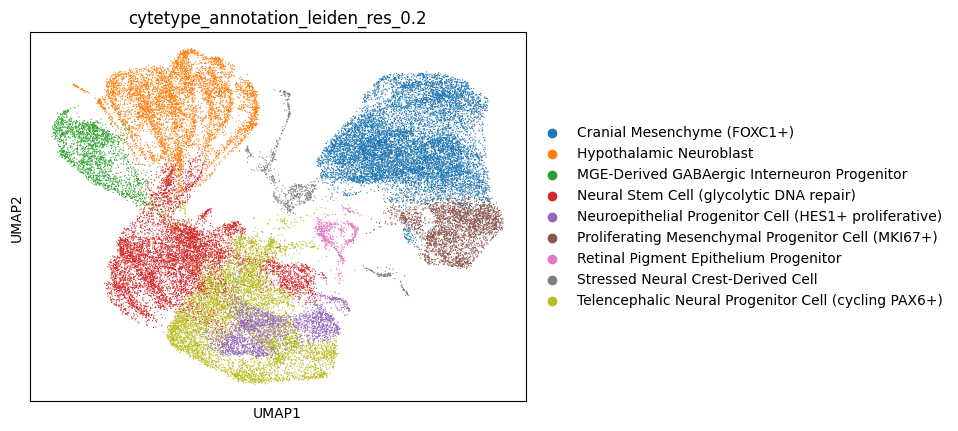

In [4]:
group_key=f"leiden_res_{res}"
annotator = CyteType(
    adata, 
    group_key=group_key, 
    rank_key='rank_genes_' + group_key, 
    gene_symbols_column="gene_symbols",
    n_top_genes=100
)

adata = annotator.run(study_context=context)

sc.pl.umap(adata, color=f'cytetype_annotation_leiden_res_{res}')